In [12]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [13]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


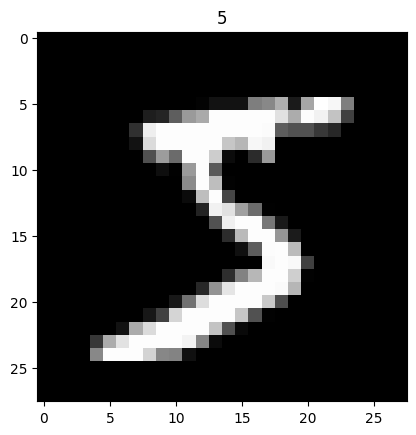

In [14]:
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

In [15]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9277 - loss: 0.2533
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9675 - loss: 0.1097
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9769 - loss: 0.0760
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9827 - loss: 0.0560
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9859 - loss: 0.0447


In [19]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0741
Accuracy: 0.9781000018119812


In [20]:
prediction = model.predict(x_test)

import numpy as np

print(np.argmax(prediction[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7


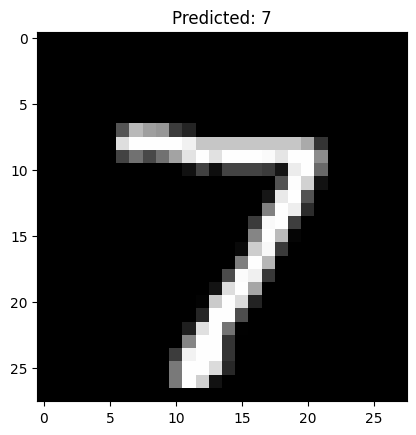

In [21]:
plt.imshow(x_test[0], cmap='gray')
plt.title("Predicted: " + str(np.argmax(prediction[0])))
plt.show()

In [22]:
model.save("handwritten_digit_model.h5")